In [6]:
# EDA | QRT-ENS Data Challenge
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42
DATA_PATH = "data/X_train.csv"


In [7]:
# 1. Data Loading & Overview
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Parse TS if possible; keep original as fallback
df["TS_parsed"] = pd.to_datetime(df["TS"], errors="coerce")
if df["TS_parsed"].isna().any():
    print(f"TS parsing: {df['TS_parsed'].isna().mean():.2%} could not be parsed; retaining original TS as well.")
else:
    print("TS parsed successfully; using TS_parsed for time analysis.")

ret_cols = sorted([c for c in df.columns if c.startswith("RET_")], key=lambda x: int(x.split("_")[1]))
vol_cols = sorted([c for c in df.columns if c.startswith("SIGNED_VOLUME_")], key=lambda x: int(x.split("_")[2]))
cat_cols = [c for c in ["ALLOCATION", "GROUP"] if c in df.columns]
id_cols = [c for c in ["ROW_ID"] if c in df.columns]
num_cols = [c for c in df.columns if c not in cat_cols + id_cols + ["TS", "TS_parsed"]]

possible_targets = [c for c in df.columns if "TARGET" in c.upper()]
print("Categorical columns:", cat_cols)
print("Numerical columns (excl. id/time):", num_cols[:10], "..." if len(num_cols) > 10 else "")
print("Potential target-like columns:", possible_targets if possible_targets else "None detected")


Shape: (527073, 45)
Columns: ['ROW_ID', 'TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9', 'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1', 'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18', 'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15', 'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12', 'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9', 'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6', 'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3', 'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP']
TS parsing: 100.00% could not be parsed; retaining original TS as well.
Categorical columns: ['ALLOCATION', 'GROUP']
Numerical columns (excl. id/time): ['RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16', 'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11'] ...
Potential target-like columns: None detected


/var/folders/cf/1zpqw8k9285c2c9m7qlkg67m0000gn/T/ipykernel_79157/1579451780.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TS_parsed"] = pd.to_datetime(df["TS"], errors="coerce")


In [8]:
df.head()

,ROW_ID,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,RET_12,RET_11,RET_10,RET_9,RET_8,RET_7,RET_6,RET_5,RET_4,RET_3,RET_2,RET_1,SIGNED_VOLUME_20,SIGNED_VOLUME_19,SIGNED_VOLUME_18,SIGNED_VOLUME_17,SIGNED_VOLUME_16,SIGNED_VOLUME_15,SIGNED_VOLUME_14,SIGNED_VOLUME_13,SIGNED_VOLUME_12,SIGNED_VOLUME_11,SIGNED_VOLUME_10,SIGNED_VOLUME_9,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP,TS_parsed
0,0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,0.005398,-0.000009,-0.009898,0.001350,0.003312,-0.009116,0.002864,-0.009067,0.001514,0.001013,-0.000178,0.003944,1.208587,1.000000,0.983866,0.712591,0.691989,0.865593,0.990404,0.876563,0.700953,0.594470,0.381315,-0.172996,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1,NaT
1,1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,-0.003374,0.001651,-0.000376,-0.000259,0.002878,0.003926,0.003323,0.000577,-0.003427,0.001383,0.000670,0.002323,-1.851427,-2.784987,-2.887732,-3.228074,-2.444007,-2.033130,-1.744573,-1.790126,-3.069280,-2.489609,-2.471619,-1.315965,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4,NaT
2,2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,0.004705,0.001653,-0.006482,0.006396,-0.002392,-0.011090,0.004384,-0.002528,-0.000569,-0.003926,-0.002696,-0.000238,1.463770,0.957351,0.379147,0.536312,1.196746,0.609863,0.366376,0.718309,1.246253,1.669319,0.858734,0.541904,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1,NaT
3,3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,-0.007674,0.003876,-0.006420,0.002596,0.000003,-0.000178,0.002725,-0.000645,-0.007703,-0.003304,0.001234,0.001863,-1.256830,-1.070127,-1.130585,-0.702706,-0.710301,-0.758426,-0.349882,-1.000000,-1.222614,-0.837973,-0.777366,-0.421041,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2,NaT
4,4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,0.001308,0.003423,0.000226,-0.000475,0.009455,0.004208,0.008469,0.000723,-0.004260,-0.002409,-0.001040,0.001219,0.700590,0.020064,-0.177706,-1.556446,-0.176596,-0.398736,-1.407239,0.729652,3.112834,1.264416,-0.390717,0.900591,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4,NaT


In [9]:
y = pd.read_csv('data/y_train.csv')
y.head()

,ROW_ID,target
0,0,0.009210
1,1,0.000405
2,2,0.005967
3,3,-0.000542
4,4,-0.002579


In [5]:
# 2. Data Quality Checks
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = missing["missing_count"] / len(df)
missing = missing.sort_values("missing_pct", ascending=False)
print("Missing values (top 15):")
display(missing.head(15))

constant_cols = [c for c in num_cols if df[c].nunique(dropna=False) <= 1]
near_constant_cols = []
for c in num_cols:
    vc = df[c].value_counts(dropna=False)
    if not vc.empty:
        top_freq = vc.iloc[0]
        if top_freq / len(df) > 0.99 and c not in constant_cols:
            near_constant_cols.append(c)
print("Constant columns:", constant_cols if constant_cols else "None")
print("Near-constant columns (top value >99%):", near_constant_cols if near_constant_cols else "None")

dupe_rows = df.duplicated().sum()
print(f"Duplicated rows: {dupe_rows} ({dupe_rows/len(df):.4%})")

# Sanity checks on returns and signed volumes
if ret_cols:
    ret_summary = df[ret_cols].agg(["min", "max", "mean", "std"])
    print("Return sanity check (min/max/mean/std):")
    display(ret_summary)
if vol_cols:
    vol_summary = df[vol_cols].agg(["min", "max", "mean", "std"])
    print("Signed volume sanity check (min/max/mean/std):")
    display(vol_summary)
if "MEDIAN_DAILY_TURNOVER" in df.columns:
    turnover_summary = df["MEDIAN_DAILY_TURNOVER"].agg(["min", "max", "mean", "std"])
    print("Turnover sanity check:")
    display(turnover_summary.to_frame().T)


Missing values (top 15):


,missing_count,missing_pct
TS_parsed,527073,1.000000
SIGNED_VOLUME_1,387506,0.735204
SIGNED_VOLUME_20,8498,0.016123
MEDIAN_DAILY_TURNOVER,3638,0.006902
SIGNED_VOLUME_19,3002,0.005696
SIGNED_VOLUME_18,859,0.001630
SIGNED_VOLUME_17,58,0.000110
RET_20,58,0.000110
SIGNED_VOLUME_16,50,0.000095
RET_19,50,0.000095


Constant columns: None
Near-constant columns (top value >99%): None
Duplicated rows: 0 (0.0000%)
Return sanity check (min/max/mean/std):


,RET_1,RET_2,RET_3,RET_4,RET_5,RET_6,RET_7,RET_8,RET_9,RET_10,RET_11,RET_12,RET_13,RET_14,RET_15,RET_16,RET_17,RET_18,RET_19,RET_20
min,-0.039351,-0.043723,-0.043676,-0.042355,-0.043621,-0.043569,-0.044076,-0.043652,-0.043437,-0.046208,-0.046217,-0.046437,-0.046168,-0.045873,-0.046619,-0.046273,-0.046368,-0.046779,-0.046987,-0.046226
max,0.129314,0.129412,0.129798,0.131141,0.129787,0.130090,0.129792,0.129302,0.129456,0.129320,0.129411,0.129300,0.129362,0.131424,0.129469,0.107983,0.129712,0.130503,0.129343,0.129840
mean,0.000079,0.000042,0.000038,0.000034,0.000032,0.000028,0.000026,0.000026,0.000026,0.000023,0.000022,0.000024,0.000026,0.000026,0.000027,0.000024,0.000025,0.000027,0.000025,0.000021
std,0.003041,0.003068,0.003058,0.003051,0.003042,0.003047,0.003048,0.003047,0.003049,0.003056,0.003059,0.003059,0.003056,0.003059,0.003061,0.003065,0.003075,0.003082,0.003089,0.003102


Signed volume sanity check (min/max/mean/std):


,SIGNED_VOLUME_1,SIGNED_VOLUME_2,SIGNED_VOLUME_3,SIGNED_VOLUME_4,SIGNED_VOLUME_5,SIGNED_VOLUME_6,SIGNED_VOLUME_7,SIGNED_VOLUME_8,SIGNED_VOLUME_9,SIGNED_VOLUME_10,SIGNED_VOLUME_11,SIGNED_VOLUME_12,SIGNED_VOLUME_13,SIGNED_VOLUME_14,SIGNED_VOLUME_15,SIGNED_VOLUME_16,SIGNED_VOLUME_17,SIGNED_VOLUME_18,SIGNED_VOLUME_19,SIGNED_VOLUME_20
min,-97.084880,-115.228750,-115.228750,-115.097120,-115.097120,-115.097120,-116.792020,-116.792020,-146.246230,-159.571580,-172.775390,-208.479080,-121.861480,-110.555040,-188.672500,-200.164250,-204.219060,-200.051120,-198.833900,-151.255330
max,36.160908,78.656590,84.008095,84.008095,85.056590,80.126700,81.463974,80.194916,79.264060,83.413760,81.524340,82.982900,66.236210,111.365814,125.028400,70.387970,65.502210,64.371870,85.870010,71.193100
mean,0.195340,0.259200,0.258928,0.258606,0.258893,0.259258,0.259768,0.260059,0.260023,0.259714,0.259446,0.258836,0.258577,0.257338,0.255774,0.255166,0.253134,0.252230,0.250505,0.247504
std,1.495215,1.583925,1.586087,1.585926,1.586910,1.584035,1.583175,1.583801,1.590091,1.591820,1.595813,1.599700,1.576420,1.583553,1.623572,1.623063,1.639422,1.631489,1.639324,1.628739


Turnover sanity check:


,min,max,mean,std
MEDIAN_DAILY_TURNOVER,6.917210e-16,1.56009,0.090944,0.236489


Summary statistics with skew/kurtosis (head):


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis
RET_1,527073.0,0.000079,0.003041,-0.039351,-0.008180,-0.004521,-0.001444,0.000062,0.001600,0.004691,0.008245,0.129314,0.384282,18.440142
RET_2,527073.0,0.000042,0.003068,-0.043723,-0.008343,-0.004659,-0.001496,0.000038,0.001598,0.004707,0.008269,0.129412,0.280378,16.883282
RET_3,527073.0,0.000038,0.003058,-0.043676,-0.008340,-0.004663,-0.001501,0.000038,0.001596,0.004703,0.008277,0.129798,0.244754,16.510978
RET_4,527073.0,0.000034,0.003051,-0.042355,-0.008331,-0.004666,-0.001507,0.000035,0.001592,0.004692,0.008226,0.131141,0.235472,16.606573
RET_5,527073.0,0.000032,0.003042,-0.043621,-0.008291,-0.004659,-0.001505,0.000035,0.001588,0.004681,0.008208,0.129787,0.228863,16.133935
RET_6,527073.0,0.000028,0.003047,-0.043569,-0.008295,-0.004681,-0.001512,0.000032,0.001589,0.004669,0.008185,0.130090,0.215432,16.000794
RET_7,527073.0,0.000026,0.003048,-0.044076,-0.008308,-0.004671,-0.001513,0.000031,0.001588,0.004661,0.008181,0.129792,0.230025,16.228079
RET_8,527073.0,0.000026,0.003047,-0.043652,-0.008344,-0.004673,-0.001517,0.000029,0.001589,0.004664,0.008185,0.129302,0.228775,16.373770
RET_9,527073.0,0.000026,0.003049,-0.043437,-0.008341,-0.004675,-0.001516,0.000030,0.001591,0.004673,0.008192,0.129456,0.232024,16.276610
RET_10,527071.0,0.000023,0.003056,-0.046208,-0.008358,-0.004696,-0.001523,0.000028,0.001594,0.004685,0.008179,0.129320,0.216857,16.187769


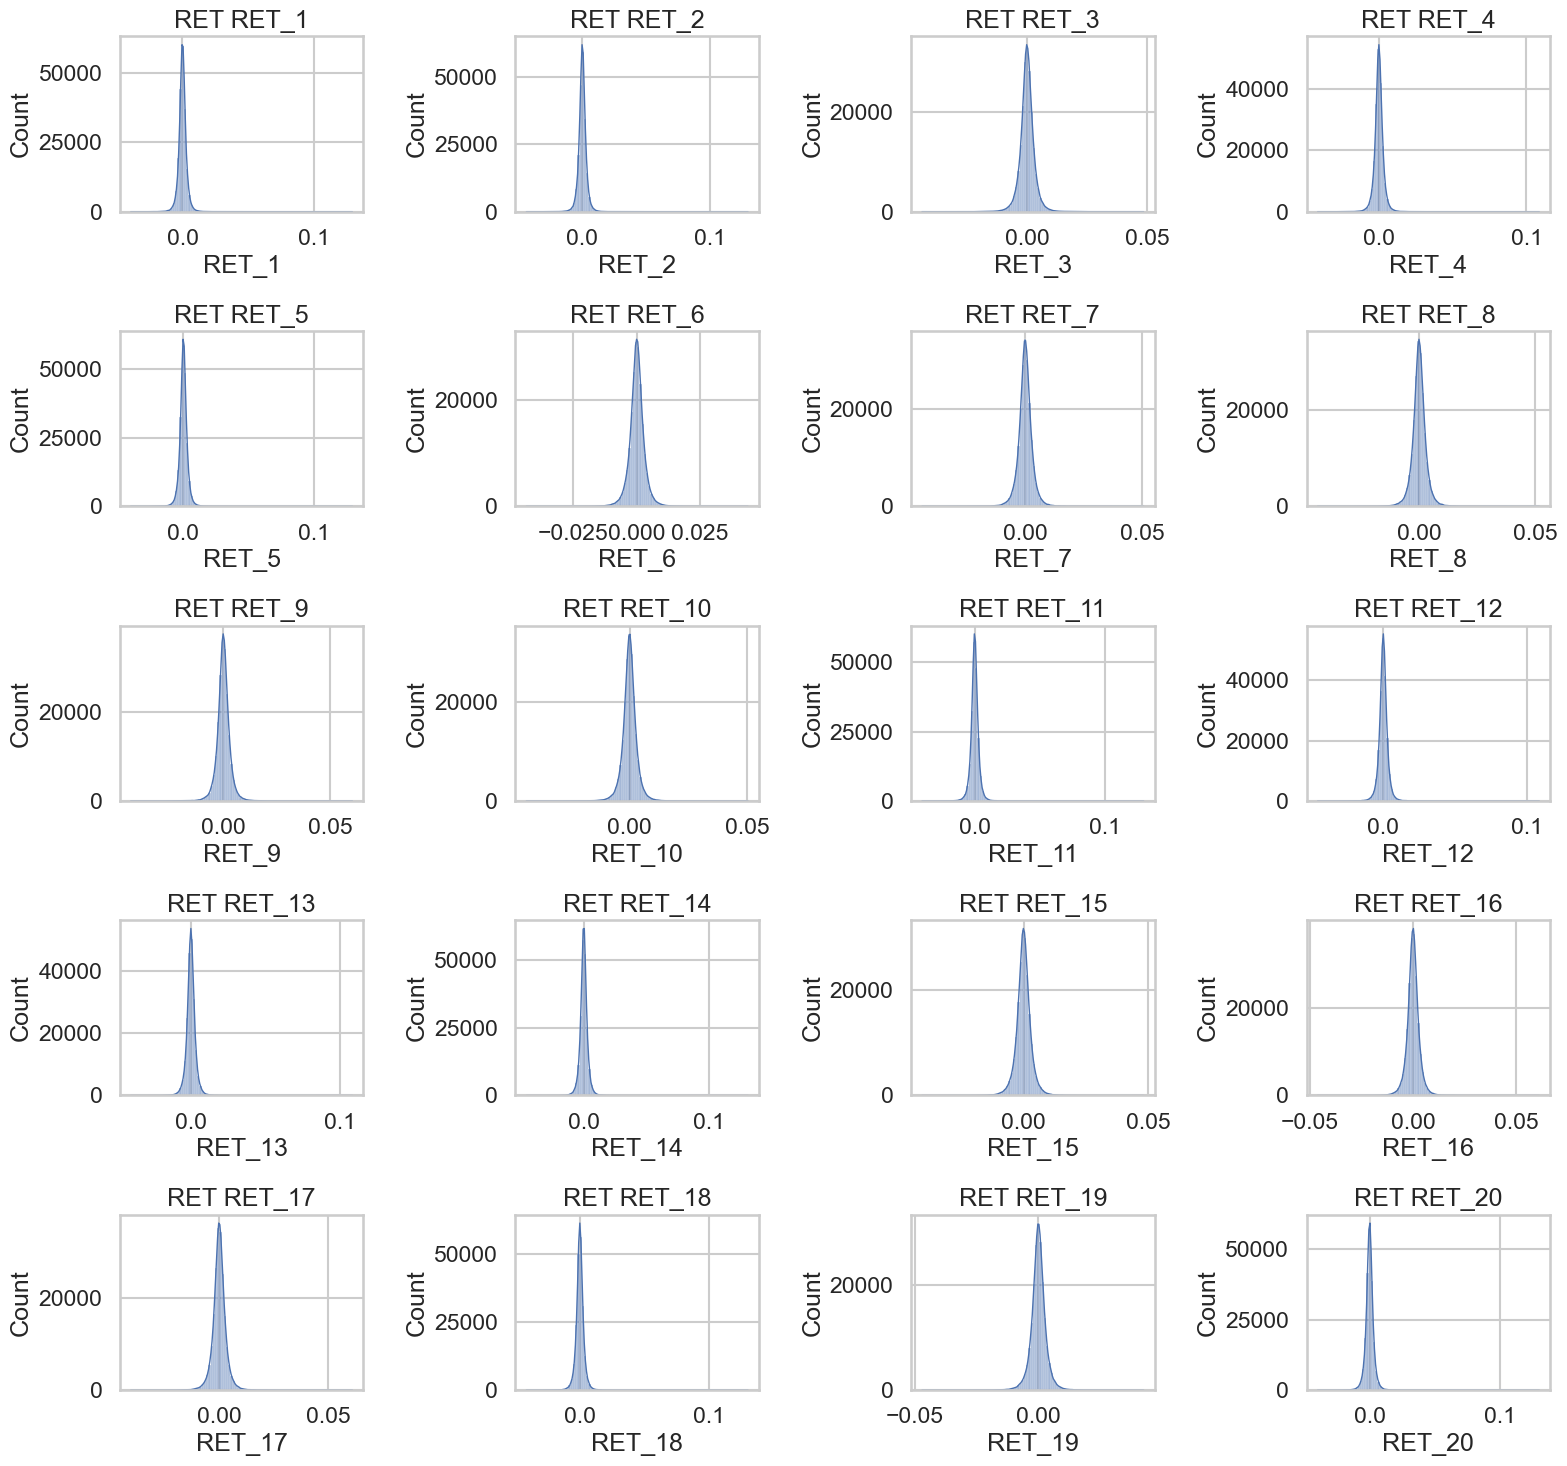

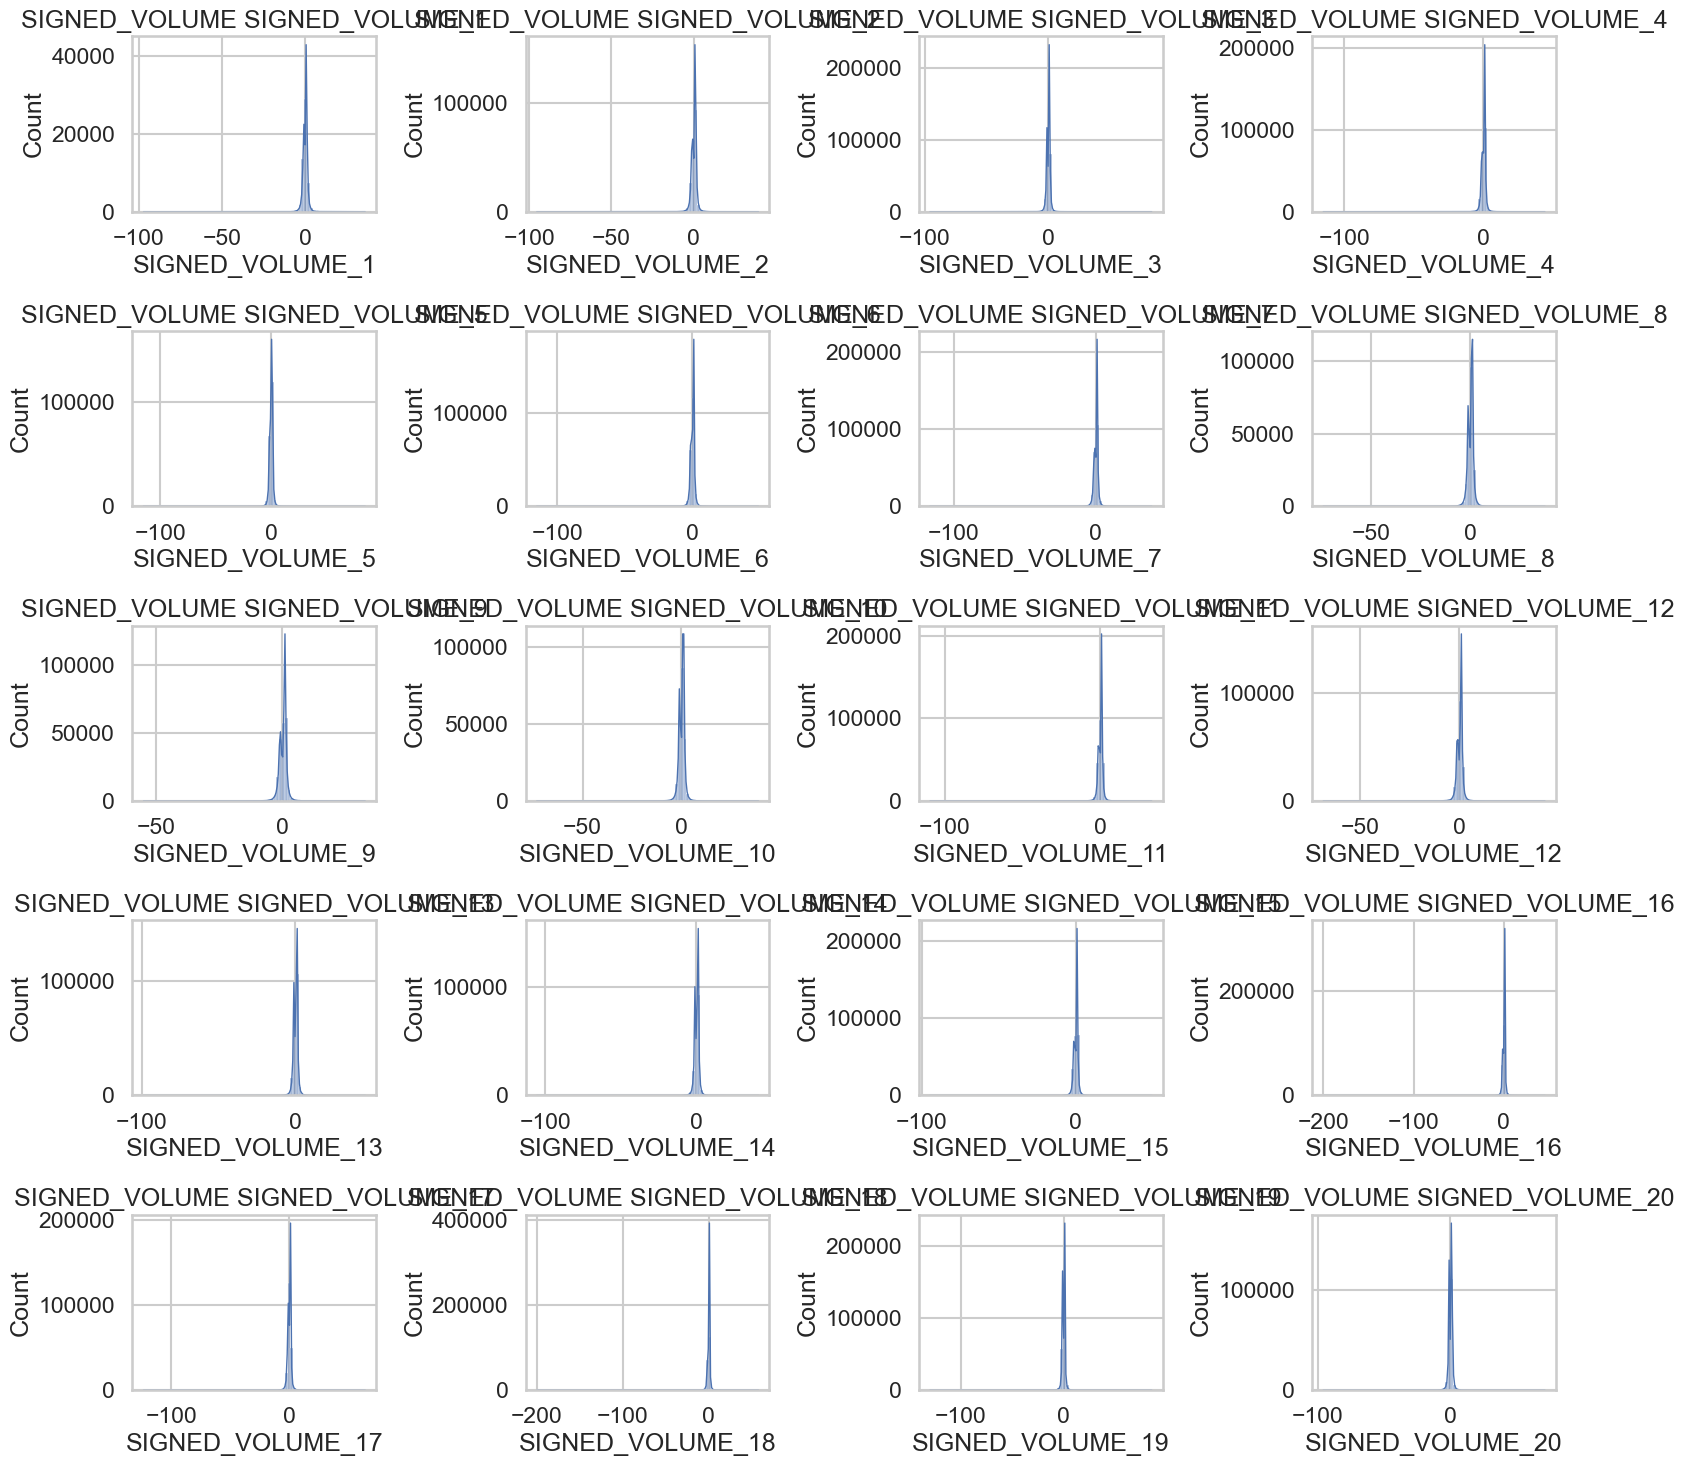

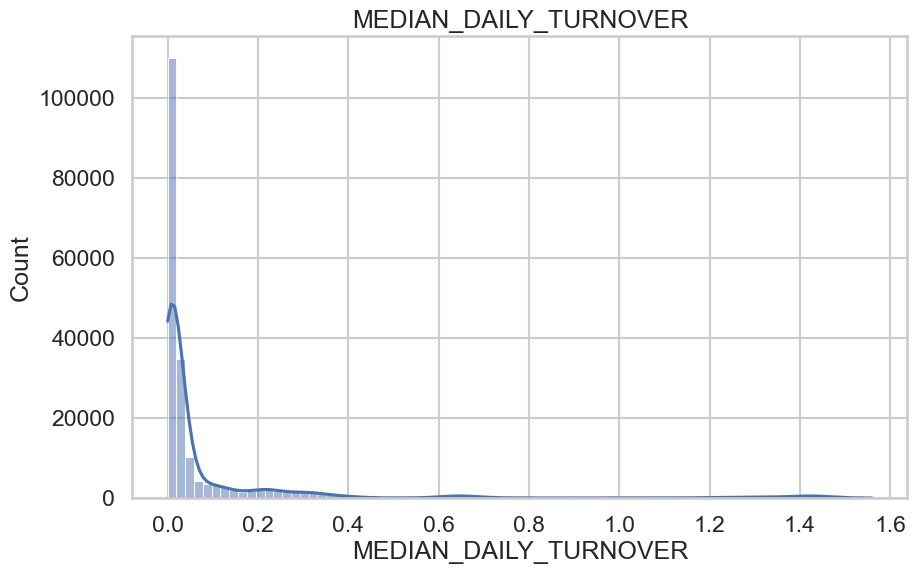

In [6]:
# 3. Univariate Analysis
numeric_focus = ret_cols + vol_cols + (["MEDIAN_DAILY_TURNOVER"] if "MEDIAN_DAILY_TURNOVER" in df.columns else [])
if numeric_focus:
    summary_stats = df[numeric_focus].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    summary_stats["skew"] = df[numeric_focus].skew()
    summary_stats["kurtosis"] = df[numeric_focus].kurtosis()
    print("Summary statistics with skew/kurtosis (head):")
    display(summary_stats.head(10))
else:
    print("No numeric features found for univariate analysis.")

# Sampling for plots to keep runtime reasonable
plot_sample = df.sample(n=min(200000, len(df)), random_state=RANDOM_STATE)

def plot_hist_kde(cols, title_prefix, bins=100):
    n = len(cols)
    if n == 0:
        return
    n_cols_plot = 4
    n_rows_plot = int(np.ceil(n / n_cols_plot))
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(4*n_cols_plot, 3*n_rows_plot))
    axes = np.array(axes).reshape(-1)
    for i, col in enumerate(cols):
        sns.histplot(plot_sample[col], kde=True, ax=axes[i], bins=bins, line_kws={"lw":1})
        axes[i].set_title(f"{title_prefix} {col}")
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

if ret_cols:
    plot_hist_kde(ret_cols, "RET")
    # Comment: look for skew/heavy tails; fat tails common in returns; note asymmetry visually.
if vol_cols:
    plot_hist_kde(vol_cols, "SIGNED_VOLUME", bins=80)
if "MEDIAN_DAILY_TURNOVER" in df.columns:
    sns.histplot(plot_sample["MEDIAN_DAILY_TURNOVER"], kde=True, bins=80)
    plt.title("MEDIAN_DAILY_TURNOVER")
    plt.show()
    # Comment: turnover typically right-skewed; consider log/Box-Cox if heavy tail.


Counts by ALLOCATION:


,count
ALLOCATION,
ALLOCATION_42,2439
ALLOCATION_59,2439
ALLOCATION_239,2439
ALLOCATION_138,2439
ALLOCATION_137,2439
...,...
ALLOCATION_214,1431
ALLOCATION_205,1431
ALLOCATION_202,1431


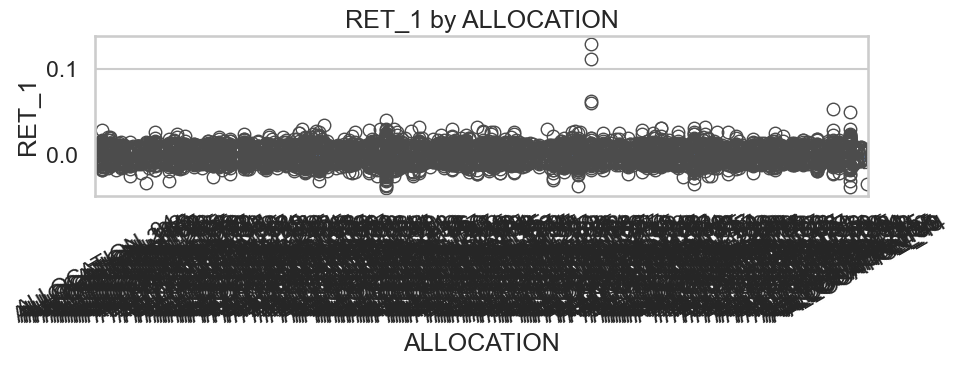

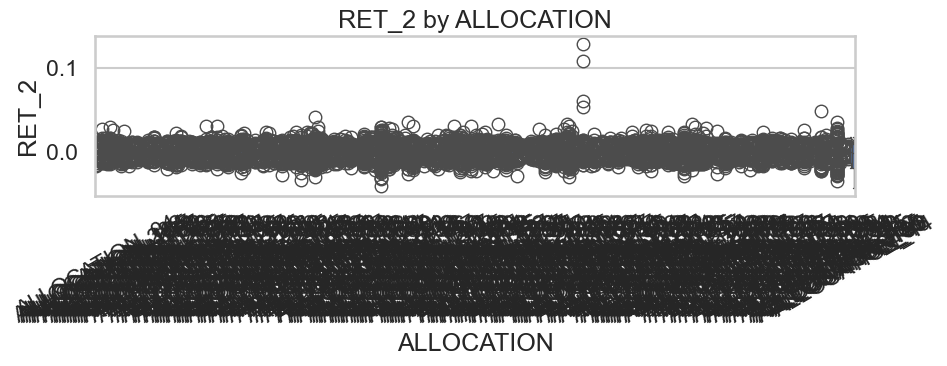

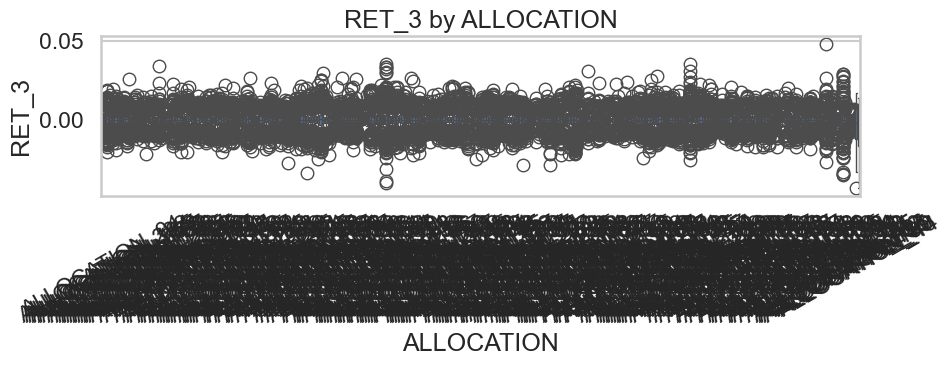

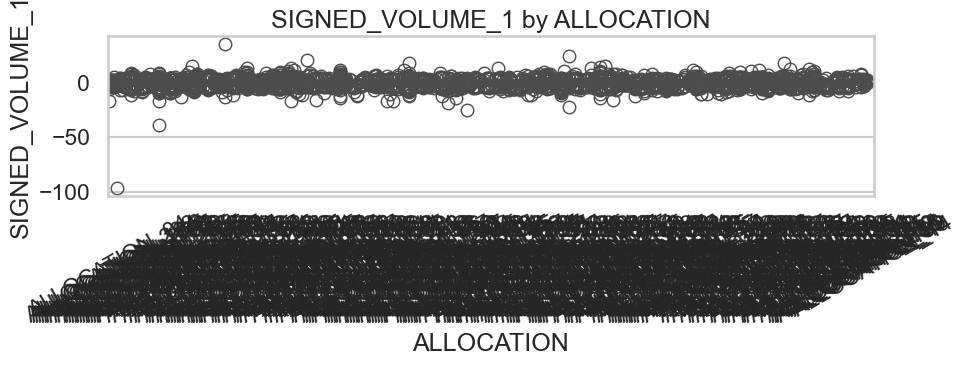

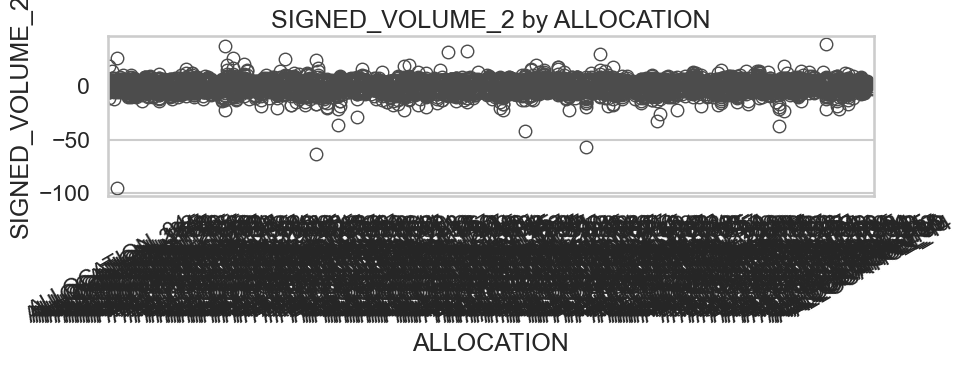

Counts by GROUP:


,count
GROUP,
3,168913
2,134928
4,123062
1,100170


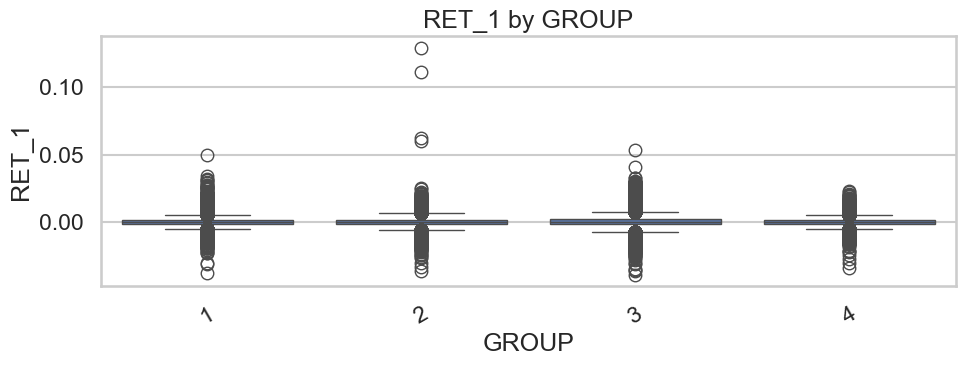

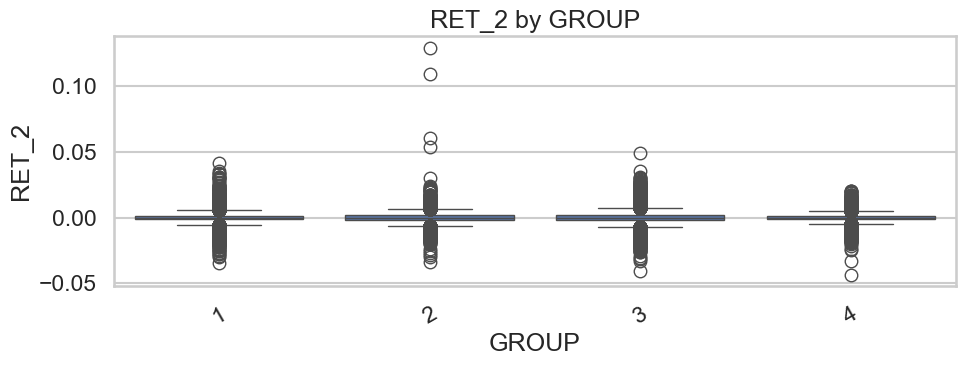

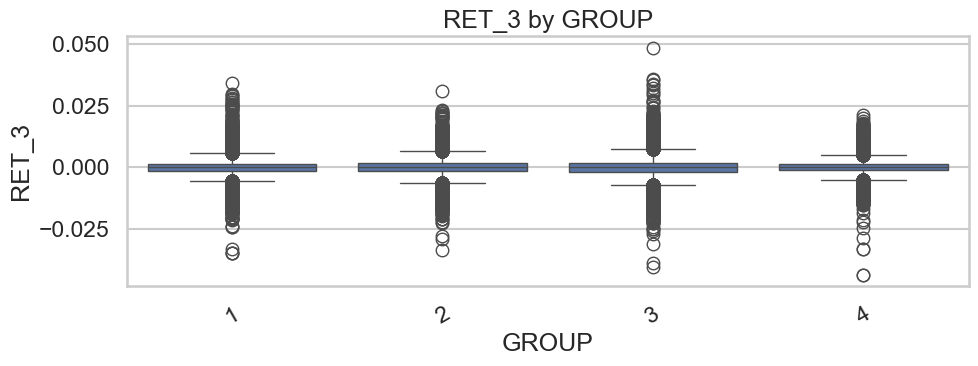

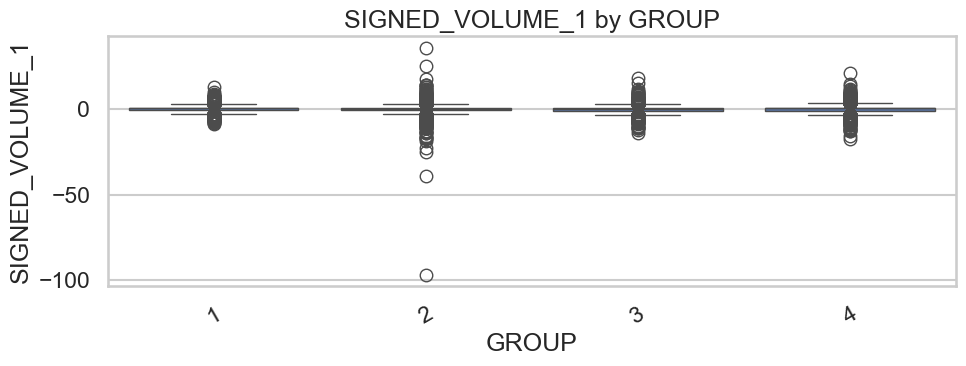

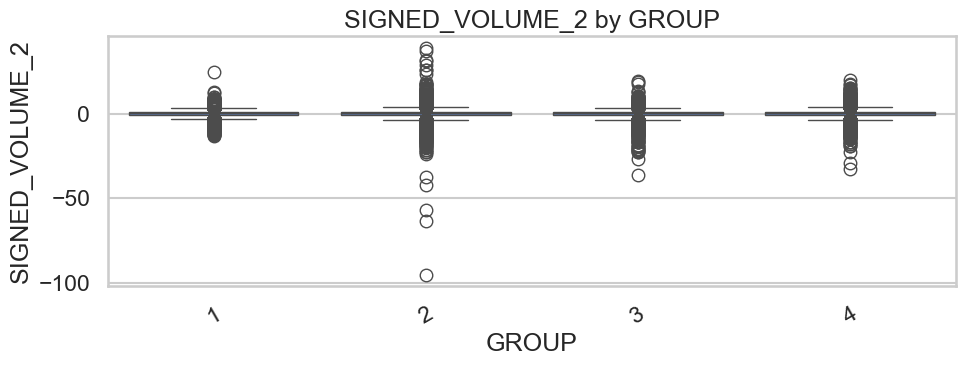

Aggregate mean/std by categorical groups (head):


RET_1               RET_2               RET_3  \
                         mean       std      mean       std      mean   
ALLOCATION    GROUP                                                     
ALLOCATION_01 1      0.000192  0.005937 -0.000085  0.006313 -0.000128   
ALLOCATION_02 4      0.000183  0.002684  0.000076  0.002729  0.000059   
ALLOCATION_03 1      0.000040  0.004113 -0.000108  0.004175 -0.000128   
ALLOCATION_04 2     -0.000074  0.003159 -0.000039  0.003155 -0.000040   
ALLOCATION_05 4      0.000144  0.004726  0.000038  0.004807  0.000028   

                                  RET_4               RET_5            \
                          std      mean       std      mean       std   
ALLOCATION    GROUP                                                     
ALLOCATION_01 1      0.006353 -0.000146  0.006406 -0.000224  0.006494   
ALLOCATION_02 4      0.002713  0.000048  0.002684  0.000042  0.002664   
ALLOCATION_03 1      0.004138 -0.000151  0.004110 -0.000186  0.004115   
ALLOCATION_04 2      0.003157 -0.000034  0.003136 -0.000035  0.003125   
ALLOCATION_05 4      0.004778  0.000031  0.004752  0.000032  0.004719   

                        RET_6               RET_7               RET_8  \
                         mean       std      mean       std      mean   
ALLOCATION    GROUP                                                     
ALLOCATION_01 1     -0.000237  0.006559 -0.000246  0.006653 -0.000259   
ALLOCATION_02 4      0.000030  0.002670  0.000028  0.002665  0.000027   
ALLOCATION_03 1     -0.000208  0.004124 -0.000223  0.004107 -0.000247   
ALLOCATION_04 2     -0.000035  0.003120 -0.000029  0.003113 -0.000023   
ALLOCATION_05 4      0.000030  0.004710  0.000032  0.004691  0.000036   

                                  RET_9                  RET_10            \
                          std      mean       std          mean       std   
ALLOCATION    GROUP                                                         
ALLOCATION_01 1      0.006738 -0.000261  0.006782 -2.574912e-04  0.006813   
ALLOCATION_02 4      0.002649  0.000015  0.002632 -2.700816e-07  0.002625   
ALLOCATION_03 1      0.004097 -0.000231  0.004086 -2.439969e-04  0.004095   
ALLOCATION_04 2      0.003118 -0.000028  0.003102 -1.888782e-05  0.003106   
ALLOCATION_05 4      0.004673  0.000023  0.004683  2.096984e-05  0.004665   

                       RET_11              RET_12              RET_13  \
                         mean       std      mean       std      mean   
ALLOCATION    GROUP                                                     
ALLOCATION_01 1     -0.000266  0.006861 -0.000248  0.006908 -0.000251   
ALLOCATION_02 4      0.000003  0.002610  0.000008  0.002606  0.000009   
ALLOCATION_03 1     -0.000238  0.004092 -0.000248  0.004117 -0.000240   
ALLOCATION_04 2     -0.000030  0.003117 -0.000039  0.003109 -0.000021   
ALLOCATION_05 4      0.000021  0.004646  0.000027  0.004643  0.000021   

                                 RET_14                  RET_15            \
                          std      mean       std          mean       std   
ALLOCATION    GROUP                                                         
ALLOCATION_01 1      0.006939 -0.000191  0.007064 -1.731690e-04  0.007091   
ALLOCATION_02 4      0.002602  0.000008  0.002593  9.231652e-07  0.002584   
ALLOCATION_03 1      0.004105 -0.000262  0.004109 -2.665845e-04  0.004109   
ALLOCATION_04 2      0.003108 -0.000038  0.003096 -2.746153e-05  0.003087   
ALLOCATION_05 4      0.004639  0.000019  0.004644  2.290376e-05  0.004630   

                       RET_16              RET_17              RET_18  \
                         mean       std      mean       std      mean   
ALLOCATION    GROUP                                                     
ALLOCATION_01 1     -0.000236  0.007183 -0.000208  0.007246 -0.000199   
ALLOCATION_02 4     -0.000002  0.002583  0.000004  0.002578  0.000001   
ALLOCATION_03 1     -0.000281  0.004109 -0.000254  0.004116 -0.000253   
ALLOCATION_0

In [7]:
# 4. Group-Level Analysis
if cat_cols:
    for cat in cat_cols:
        print(f"Counts by {cat}:")
        display(df[cat].value_counts(dropna=False).to_frame("count"))
        for feature in ret_cols[:3] + vol_cols[:2]:
            plt.figure(figsize=(10,4))
            sns.boxplot(data=plot_sample, x=cat, y=feature)
            plt.title(f"{feature} by {cat}")
            plt.xticks(rotation=30)
            plt.tight_layout()
            plt.show()

    agg_cols = ret_cols + vol_cols + (["MEDIAN_DAILY_TURNOVER"] if "MEDIAN_DAILY_TURNOVER" in df.columns else [])
    grouped_stats = df.groupby(cat_cols)[agg_cols].agg(["mean", "std"])
    print("Aggregate mean/std by categorical groups (head):")
    display(grouped_stats.head())
else:
    print("No categorical columns found for group-level analysis.")


In [8]:
# 5. Time Dimension Analysis
time_col = "TS_parsed" if "TS_parsed" in df.columns else "TS"
if time_col not in df.columns or df[time_col].isna().all():
    print("Time column unavailable or not parsed; skipping time analysis.")
elif not ret_cols:
    print("No return features to analyze over time.")
else:
    df_time_sorted = df.sort_values(time_col)
    time_means = df_time_sorted.groupby(time_col)[ret_cols].mean()
    window = max(10, min(200, max(10, len(time_means)//10)))
    rolling_mean = time_means.rolling(window=window, min_periods=max(5, window//2)).mean()
    rolling_std = time_means.rolling(window=window, min_periods=max(5, window//2)).std()

    focus_rets = ret_cols[:3]
    for col in focus_rets:
        plt.figure(figsize=(12,4))
        plt.plot(time_means.index, time_means[col], label="Mean")
        plt.plot(rolling_mean.index, rolling_mean[col], label=f"Rolling mean (w={window})", color="orange")
        plt.title(f"{col} mean over time")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(12,4))
        plt.plot(rolling_std.index, rolling_std[col], label=f"Rolling std (w={window})", color="red")
        plt.title(f"{col} rolling std over time")
        plt.legend()
        plt.tight_layout()
        plt.show()
    # Comment: watch for non-stationarity or volatility clustering across TS.


Time column unavailable or not parsed; skipping time analysis.


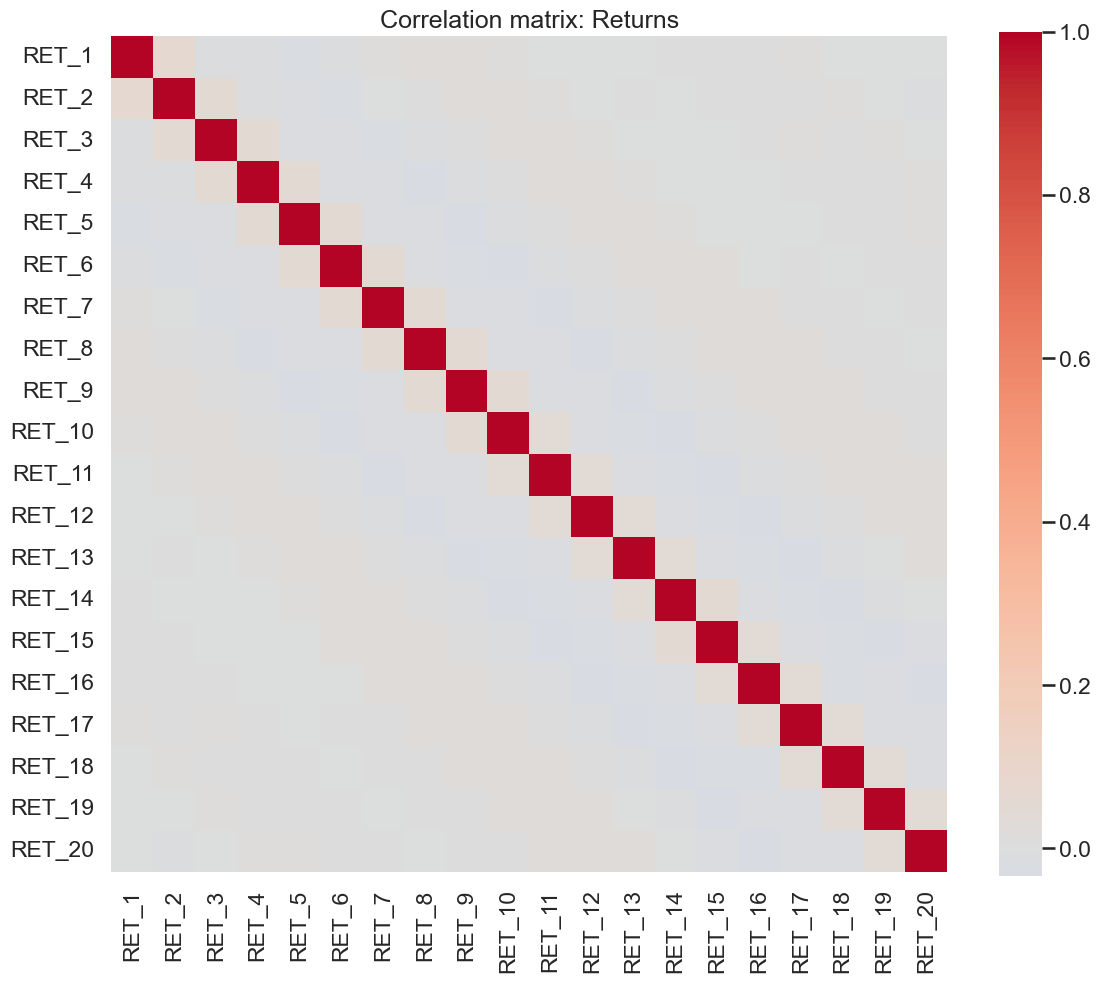

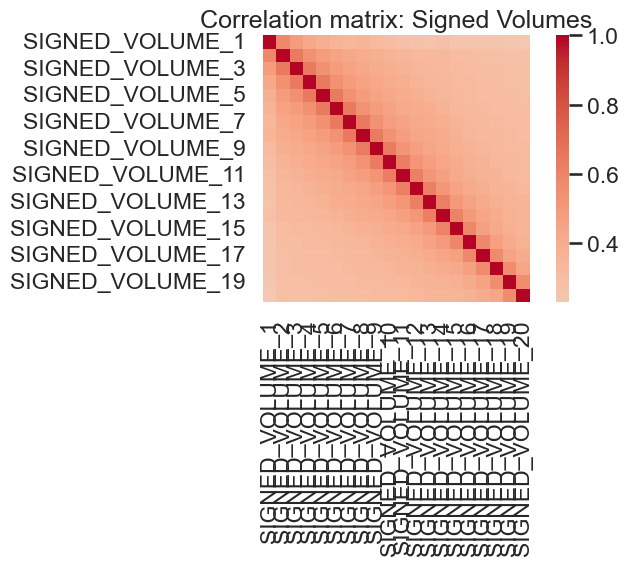

Highly correlated return pairs (|corr|>=0.9): None
Highly correlated volume pairs (|corr|>=0.9): None


In [9]:
# 6. Multivariate Analysis
if ret_cols:
    corr_ret = df[ret_cols].corr()
    plt.figure(figsize=(12,10))
    sns.heatmap(corr_ret, cmap="coolwarm", center=0, square=True)
    plt.title("Correlation matrix: Returns")
    plt.tight_layout()
    plt.show()
if vol_cols:
    corr_vol = df[vol_cols].corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr_vol, cmap="coolwarm", center=0, square=True)
    plt.title("Correlation matrix: Signed Volumes")
    plt.tight_layout()
    plt.show()

# Identify multicollinearity pairs |corr| > 0.9
def high_corr_pairs(corr_mat, threshold=0.9):
    pairs = []
    cols = corr_mat.columns
    for i in range(len(cols)):
        for j in range(i):
            val = corr_mat.iloc[i, j]
            if abs(val) >= threshold:
                pairs.append((cols[i], cols[j], val))
    return sorted(pairs, key=lambda x: abs(x[2]), reverse=True)

if ret_cols:
    strong_pairs = high_corr_pairs(corr_ret)
    print("Highly correlated return pairs (|corr|>=0.9):", strong_pairs[:10] if strong_pairs else "None")
if vol_cols:
    strong_pairs_vol = high_corr_pairs(corr_vol)
    print("Highly correlated volume pairs (|corr|>=0.9):", strong_pairs_vol[:10] if strong_pairs_vol else "None")


/var/folders/cf/1zpqw8k9285c2c9m7qlkg67m0000gn/T/ipykernel_79721/787156912.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


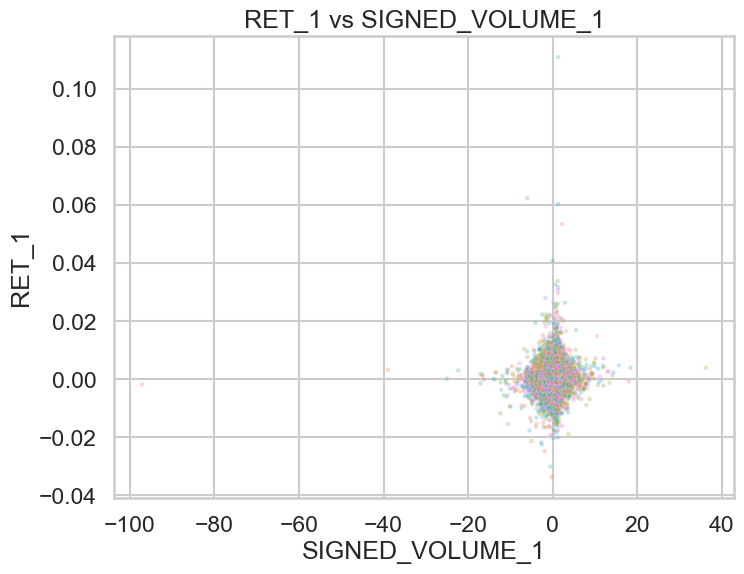

/var/folders/cf/1zpqw8k9285c2c9m7qlkg67m0000gn/T/ipykernel_79721/787156912.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


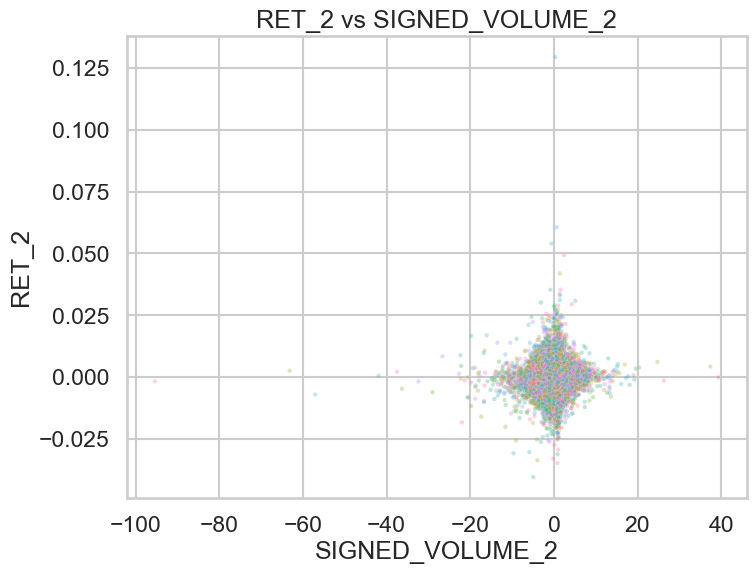

/var/folders/cf/1zpqw8k9285c2c9m7qlkg67m0000gn/T/ipykernel_79721/787156912.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


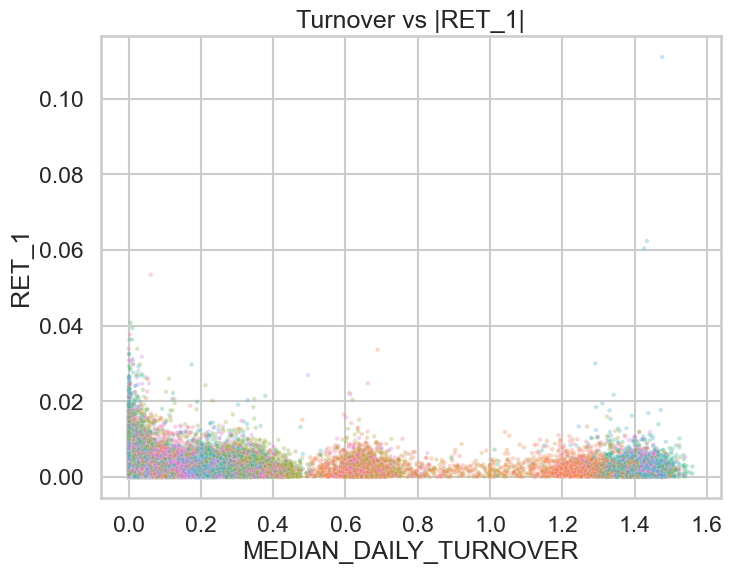

In [13]:
# 7. Feature Relationships
rel_sample = df.sample(n=min(150000, len(df)), random_state=RANDOM_STATE)
hue_col = cat_cols[0] if cat_cols else None

if ret_cols and vol_cols:
    pairings = list(zip(ret_cols[:2], vol_cols[:2]))
    for r, v in pairings:
        plt.figure(figsize=(8,6))
        sns.scatterplot(data=rel_sample, x=v, y=r, hue=hue_col, alpha=0.3, s=10)
        plt.title(f"{r} vs {v}")
        plt.tight_layout()
        plt.legend().remove()        
        plt.show()
        # Comment: positive slope implies price impact from signed volume.

if "MEDIAN_DAILY_TURNOVER" in df.columns and ret_cols:
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=rel_sample, x="MEDIAN_DAILY_TURNOVER", y=rel_sample[ret_cols[0]].abs(), hue=hue_col, alpha=0.3, s=10)
    plt.title(f"Turnover vs |{ret_cols[0]}|")
    plt.tight_layout()
    plt.legend().remove()
    plt.show()
    # Comment: check whether liquidity (turnover) tempers or amplifies absolute returns.


Top features by z-score outlier rate:


,feature,z>3_pct,IQR_outlier_pct
40,MEDIAN_DAILY_TURNOVER,0.026977,0.169665
2,RET_3,0.014296,0.048830
15,RET_16,0.014245,0.048699
3,RET_4,0.014220,0.048616
1,RET_2,0.014209,0.048940
17,RET_18,0.014163,0.048441
7,RET_8,0.014118,0.047775
4,RET_5,0.014095,0.048352
5,RET_6,0.014087,0.048022
16,RET_17,0.014087,0.048500


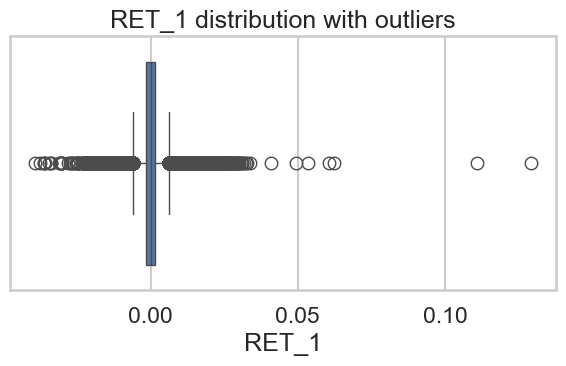

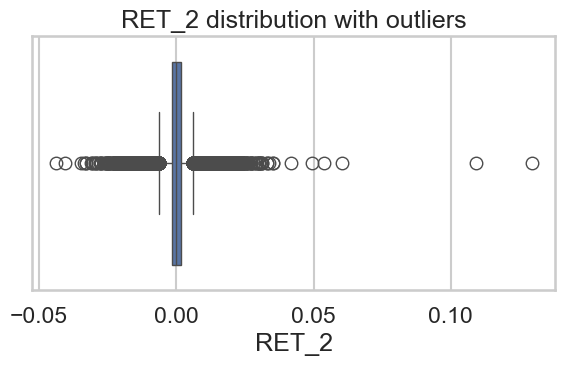

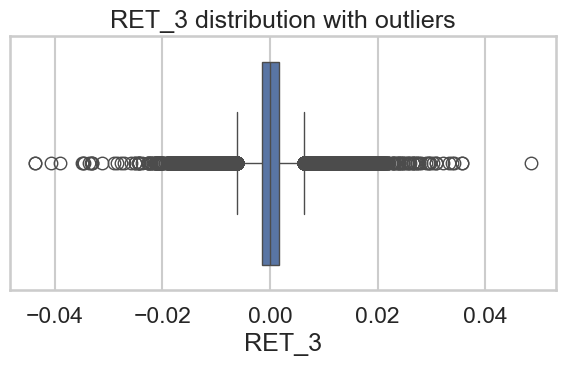

In [11]:
# 8. Outlier Analysis
if numeric_focus:
    outlier_report = []
    for col in numeric_focus:
        col_std = df[col].std(ddof=0)
        col_mean = df[col].mean()
        if col_std == 0:
            extreme_frac = 0.0
            iqr_frac = 0.0
        else:
            col_z = (df[col] - col_mean) / col_std
            extreme_frac = (col_z.abs() > 3).mean()
            q1, q3 = df[col].quantile([0.25, 0.75])
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            iqr_frac = ((df[col] < lower) | (df[col] > upper)).mean()
        outlier_report.append({"feature": col, "z>3_pct": extreme_frac, "IQR_outlier_pct": iqr_frac})
    outlier_df = pd.DataFrame(outlier_report).sort_values("z>3_pct", ascending=False)
    print("Top features by z-score outlier rate:")
    display(outlier_df.head(10))

    for col in ret_cols[:3]:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=plot_sample[col])
        plt.title(f"{col} distribution with outliers")
        plt.tight_layout()
        plt.show()
        # Comment: fat tails expected; consider clipping/winsorizing in modeling.
else:
    print("No numeric features for outlier analysis.")


In [12]:
# 9. EDA Conclusions (comments only)
"""
Key patterns:
- Returns likely heavy-tailed / skewed; rolling std can reveal volatility clustering over TS.
- Signed volumes show directional effect; strong lag collinearity suggests dimensionality reduction may help.
- GROUP/ALLOCATION may shift distributions; encode and test interactions.
Potential risks:
- Non-stationarity across TS; use time-aware splits and rolling normalization.
- Near-constant features add noise; drop or regularize.
- Watch for leakage via time index or any hidden target-like cols once labels provided.
Feature engineering ideas:
- Winsorize tails; scale returns by rolling volatility.
- Build signed-volume imbalances and turnover-adjusted features.
- Add rolling means/EMAs for RET_* and SIGNED_VOLUME_*; encode GROUP/ALLOCATION.
"""


'\nKey patterns:\n- Returns likely heavy-tailed / skewed; rolling std can reveal volatility clustering over TS.\n- Signed volumes show directional effect; strong lag collinearity suggests dimensionality reduction may help.\n- GROUP/ALLOCATION may shift distributions; encode and test interactions.\nPotential risks:\n- Non-stationarity across TS; use time-aware splits and rolling normalization.\n- Near-constant features add noise; drop or regularize.\n- Watch for leakage via time index or any hidden target-like cols once labels provided.\nFeature engineering ideas:\n- Winsorize tails; scale returns by rolling volatility.\n- Build signed-volume imbalances and turnover-adjusted features.\n- Add rolling means/EMAs for RET_* and SIGNED_VOLUME_*; encode GROUP/ALLOCATION.\n'